In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [4]:
# ════════════════════════════════════════════════════════════
# CELLULE URGENCE — Redémarre tout proprement
# ════════════════════════════════════════════════════════════

import subprocess, time, requests

# 1. Démarre Ollama
subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
time.sleep(8)

# 2. Vérifie
try:
    requests.get("http://localhost:11434", timeout=5)
    print("✅ Ollama tourne")
except:
    print("❌ Ollama ne répond pas")
    raise SystemExit()

# 3. Retélécharge les modèles
print("⬇️  Téléchargement nomic-embed-text...")
!ollama pull nomic-embed-text

print("⬇️  Téléchargement qwen2.5:7b...")
!ollama pull qwen2.5:7b

# 4. Vérifie les modèles disponibles
!ollama list

print("\n✅ Tout est prêt — relance maintenant la cellule ingestion !")

✅ Ollama tourne
⬇️  Téléchargement nomic-embed-text...
]11;?\pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠧ pulling manifest ⠇ pulling manifest ⠏ pulling manifest 
pulling 970aa74c0a90:   0% ▕                  ▏ 114 KB/274 MB                  pulling manifest 
pulling 970aa74c0a90:  13% ▕██                ▏  34 MB/274 MB                  pulling manifest 
pulling 970aa74c0a90:  20% ▕███               ▏  53 MB/274 MB                  pulling manifest 
pulling 970aa74c0a90:  36% ▕██████            ▏  98 MB/274 MB                  pulling manifest 
pulling 970aa74c0a90:  48% ▕████████          ▏ 132 MB/274 MB                  pulling manifest 
pulling 970aa74c0a90:  54% ▕█████████         ▏ 148 MB/274 MB                  pulling manifest 
pulling 970aa74c0a90:  73% ▕█████████████     ▏ 200 MB/274 MB                  pulling manifest 
pulling 970aa74c0a90:  88% ▕███████████████   ▏ 24

In [5]:
!apt-get install -y zstd
!curl -fsSL https://ollama.com/install.sh | sh
!pip install -q pyngrok gradio chromadb langchain langchain-community langchain-text-splitters pdfplumber beautifulsoup4 requests sentence-transformers openai
 
print("✅ Installation terminée — 2")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
zstd is already the newest version (1.4.8+dfsg-3build1).
0 upgraded, 0 newly installed, 0 to remove and 133 not upgraded.
>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%                                                34.4%
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.
✅ Installation terminée — 2


In [ ]:
# ════════════════════════════════════════════════════════════
# CELLULE INGESTION FINALE — versions à jour
# ════════════════════════════════════════════════════════════

!pip install -q langchain-ollama langchain-chroma

import subprocess, time, requests, os, shutil
from bs4 import BeautifulSoup
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_ollama import OllamaEmbeddings        # ← nouveau
from langchain_chroma import Chroma                  # ← nouveau
import chromadb

# ── Démarre Ollama ────────────────────────────────────────────
subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
time.sleep(8)
try:
    requests.get("http://localhost:11434", timeout=5)
    print("✅ Ollama tourne")
except:
    print("❌ Relance cette cellule")
    raise SystemExit()

WEB_SOURCES = [
    {"url": "https://startup.gov.tn/fr/startup_act/benefits_to_Startups",      "titre": "Avantages Startups — Startup Act",           "domaine": "avantages_startup",    "langue": "fr"},
    {"url": "https://startup.gov.tn/fr/startup_act/benefits_to_entrepreneurs", "titre": "Avantages Entrepreneurs — Startup Act",       "domaine": "avantages_entrepreneur","langue": "fr"},
    {"url": "https://startup.gov.tn/fr/startup_act/benefits_to_investors",     "titre": "Avantages Investisseurs — Startup Act",       "domaine": "avantages_investisseur","langue": "fr"},
    {"url": "https://startup.gov.tn/fr/startup_act/how_to_obtain_the_label",   "titre": "Comment obtenir le label Startup",            "domaine": "label_startup",         "langue": "fr"},
    {"url": "https://startup.gov.tn/en/startup_act/discover",                  "titre": "Startup Act — Vue d'ensemble",                "domaine": "startup_act_overview",  "langue": "en"},
    {"url": "https://www.mtc.gov.tn/index.php?L=1&id=startupact",             "titre": "Startup Act — Ministère des Technologies",    "domaine": "startup_act_mtc",       "langue": "fr"},
    {"url": "https://chaexpert.com/tunisie-loi-de-finances-2026/",             "titre": "LF 2026 — Analyse fiscale complète",          "domaine": "loi_finances",          "langue": "fr"},
    {"url": "https://chaexpert.com/tunisie-projet-de-loi-de-finances-2026/",   "titre": "LF 2026 — Projet initial mesures fiscales",   "domaine": "loi_finances",          "langue": "fr"},
    {"url": "https://pm.gov.tn/fr/detail-decision/2840",                       "titre": "LF 2026 — Présentation gouvernement",         "domaine": "loi_finances",          "langue": "fr"},
    {"url": "https://businessnews.com.tn/2025/12/12/kais-saied-promulgue-la-loi-de-finances-2026/1378342/", "titre": "LF 2026 — Promulgation officielle JORT", "domaine": "loi_finances", "langue": "fr"},
    {"url": "https://www.finances.gov.tn/fr/loi_finance",                      "titre": "Ministère des Finances — Lois de finances",   "domaine": "loi_finances",          "langue": "fr"},
]

def scrape(item):
    headers = {"User-Agent": "Mozilla/5.0", "Accept-Language": "fr,ar;q=0.9,en;q=0.8"}
    try:
        resp = requests.get(item["url"], headers=headers, timeout=20)
        resp.encoding = "utf-8"
        soup = BeautifulSoup(resp.text, "html.parser")
        for tag in soup(["nav","header","footer","script","style","aside","form"]):
            tag.decompose()
        main  = soup.find("main") or soup.find("article") or soup.find("body")
        text  = main.get_text(separator="\n", strip=True) if main else ""
        lines = [l.strip() for l in text.splitlines() if len(l.strip()) > 20]
        clean = "\n".join(lines)
        if len(clean) > 200:
            return Document(page_content=clean, metadata={"source": item["url"], "titre": item["titre"], "domaine": item["domaine"], "langue": item["langue"]})
        return None
    except:
        return None

docs = []
print("\n🌐 Scraping...")
for item in WEB_SOURCES:
    flag = "🇸🇦" if item["langue"]=="ar" else "🇫🇷" if item["langue"]=="fr" else "🇬🇧"
    doc = scrape(item)
    if doc:
        docs.append(doc)
        print(f"  ✅ {flag} {item['titre']} — {len(doc.page_content)} chars")
    else:
        print(f"  ⚠️  {flag} {item['titre']} — ignoré")

print(f"\n📊 {len(docs)} documents")

splitter = RecursiveCharacterTextSplitter(chunk_size=800, chunk_overlap=120, separators=["\n\n","\n","."," "])
chunks   = splitter.split_documents(docs)
print(f"✂️  {len(chunks)} chunks créés")

CHROMA_DIR = "/kaggle/temp/chroma_db"
if os.path.exists(CHROMA_DIR):
    shutil.rmtree(CHROMA_DIR)
os.makedirs(CHROMA_DIR, exist_ok=True)

print("\n🧠 Indexation ChromaDB...")
embeddings  = OllamaEmbeddings(model="nomic-embed-text", base_url="http://localhost:11434")
client      = chromadb.PersistentClient(path=CHROMA_DIR)
vectorstore = Chroma(client=client, collection_name="startupfinance_tn", embedding_function=embeddings)

for i in range(0, len(chunks), 10):
    batch = chunks[i:i+10]
    vectorstore.add_documents(batch)
    print(f"  ✅ Lot {i//10+1}/{(len(chunks)-1)//10+1}")

print(f"\n✅ Base prête — {vectorstore._collection.count()} chunks indexés")
print("👉 Lance maintenant la cellule RAG + Chat")

In [27]:
# ════════════════════════════════════════════════════════════
# CELLULE RAG + CHAT — version finale
# ════════════════════════════════════════════════════════════

import gradio as gr, chromadb
from openai import OpenAI
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import OllamaEmbeddings
from pyngrok import ngrok, conf
from kaggle_secrets import UserSecretsClient

# ── Recharge vectorstore ──────────────────────────────────────
embeddings  = OllamaEmbeddings(model="nomic-embed-text", base_url="http://localhost:11434")
client_db   = chromadb.PersistentClient(path="/root/chroma_db")
vectorstore = Chroma(client=client_db, collection_name="startupfinance_tn", embedding_function=embeddings)
print(f"✅ Vectorstore : {vectorstore._collection.count()} chunks")

# ── Client Ollama ─────────────────────────────────────────────
llm = OpenAI(api_key="ollama", base_url="http://localhost:11434/v1")

SYSTEM_PROMPT = """Tu es FiskoBot, un assistant financier expert sur l'écosystème startup tunisien.
Tu aides les fondateurs, entrepreneurs et investisseurs à comprendre :
- Les avantages financiers du Startup Act tunisien
- Les dispositions fiscales de la Loi de Finances 2026
- Les mécanismes de financement, exonérations, et aides disponibles

Règles :
1. Réponds UNIQUEMENT en te basant sur le contexte fourni.
2. Si l'info est absente, dis-le clairement.
3. Cite toujours la source.
4. Sois précis sur les chiffres et conditions.
5. Réponds en français sauf si l'utilisateur écrit en arabe ou anglais."""

def ask(question, history=None):
    docs    = vectorstore.similarity_search(question, k=5)
    context = "\n\n---\n\n".join([f"[{d.metadata.get('titre','')}]\n{d.page_content}" for d in docs])
    messages = [{"role": "system", "content": SYSTEM_PROMPT}]
    if history:
        for u, b in history[-4:]:
            messages += [{"role":"user","content":u},{"role":"assistant","content":b}]
    messages.append({"role": "user", "content": f"Contexte :\n{context}\n\nQuestion : {question}"})
    try:
        resp   = llm.chat.completions.create(model="qwen2.5:7b", messages=messages, max_tokens=1500, temperature=0.1)
        answer = resp.choices[0].message.content
    except Exception as e:
        answer = f"❌ Erreur : {e}"
    sources = list({d.metadata.get("titre","") for d in docs})
    return {"answer": answer, "sources": sources}

# ── Interface Gradio ──────────────────────────────────────────
SUGGESTIONS = [
    "Quels sont les avantages fiscaux pour une startup labellisée ?",
    "Comment obtenir le label Startup Act en Tunisie ?",
    "Qu'est-ce que la carte technologique à 100k TND ?",
    "Une startup est-elle exonérée de TVA ?",
    "Quels avantages ont les investisseurs dans les startups ?",
    "Quelles sont les mesures PME dans la LF 2026 ?",
]

def respond(message, history):
    if not message.strip():
        return "", history
    result = ask(message, [(h[0],h[1]) for h in history if h[0] and h[1]])
    answer = result["answer"]
    if result["sources"]:
        answer += "\n\n---\n📚 **Sources :** " + " · ".join(result["sources"])
    history.append((message, answer))
    return "", history

with gr.Blocks(title="FiskoBot 🇹🇳") as demo:
    gr.HTML("""<div style="text-align:center;padding:16px 0 8px">
        <h1 style="font-size:1.8rem;margin:0">🇹🇳 FiskoBot</h1>
        <p style="color:#555;margin:6px 0 0">Assistant financier IA — Startup Act & Loi de Finances 2026</p>
    </div>""")
    with gr.Row():
        with gr.Column(scale=3):
            chatbot = gr.Chatbot(height=480, type="messages", show_copy_button=True)
            with gr.Row():
                msg = gr.Textbox(placeholder="Pose ta question...", show_label=False, scale=5, container=False)
                btn = gr.Button("Envoyer ▶", variant="primary", scale=1)
            gr.Button("🗑️ Nouvelle conversation", size="sm").click(lambda: ([], ""), outputs=[chatbot, msg])
        with gr.Column(scale=1):
            gr.Markdown("### 💡 Questions fréquentes")
            for q in SUGGESTIONS:
                gr.Button(q[:55]+"..." if len(q)>55 else q, size="sm").click(fn=lambda x=q: x, outputs=msg)

    msg.submit(respond, [msg, chatbot], [msg, chatbot])
    btn.click(respond,  [msg, chatbot], [msg, chatbot])
    demo.load(fn=lambda: [{"role":"assistant","content":"👋 Bonjour ! Je suis **FiskoBot**.\nPose ta question sur le **Startup Act** ou la **LF 2026** !"}], outputs=chatbot)

# ── ngrok ─────────────────────────────────────────────────────
secrets = UserSecretsClient()
conf.get_default().auth_token = secrets.get_secret("HF_TOKEN")
ngrok.kill()
tunnel = ngrok.connect(7860, "http")

✅ Vectorstore : 59 chunks


/tmp/ipykernel_57/1771465705.py:77: DeprecationWarning: The 'show_copy_button' parameter will be removed in Gradio 6.0. You will need to use 'buttons=["copy"]' instead.
  chatbot = gr.Chatbot(height=480, type="messages", show_copy_button=True)
/tmp/ipykernel_57/1771465705.py:77: DeprecationWarning: The default value of 'allow_tags' in gr.Chatbot will be changed from False to True in Gradio 6.0. You will need to explicitly set allow_tags=False if you want to disable tags in your chatbot.
  chatbot = gr.Chatbot(height=480, type="messages", show_copy_button=True)


In [29]:
# ════════════════════════════════════════════════════════════
# CELLULE — Afficher l'URL ngrok
# ════════════════════════════════════════════════════════════

from pyngrok import ngrok

tunnels = ngrok.get_tunnels()
if tunnels:
    for t in tunnels:
        print(f"🔗 URL : {t.public_url}")
else:
    # Crée un nouveau tunnel si aucun n'existe
    from pyngrok import conf
    from kaggle_secrets import UserSecretsClient
    secrets = UserSecretsClient()
    conf.get_default().auth_token = secrets.get_secret("hf_tokn")
    tunnel = ngrok.connect(7860, "http")
    print(f"🔗 URL : {tunnel.public_url}")

🔗 URL : https://c8c0-35-185-62-68.ngrok-free.app


2026-04-29 06:16:45.021190: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777443405.273402      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777443405.335739      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777443405.905592      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777443405.905622      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777443405.905625      57 computation_placer.cc:177] computation placer alr

🔄 Récupération des vecteurs depuis ChromaDB...
✅ 59 vecteurs récupérés — 768 dimensions chacun
🧠 Réduction UMAP en cours (768 dimensions → 2D)...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✅ Réduction terminée

🔍 Simulation RAG pour : 'avantages fiscaux startup labellisée'


/tmp/ipykernel_57/1452051264.py:117: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/1452051264.py:118: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("/kaggle/working/xai_umap.png", dpi=150, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


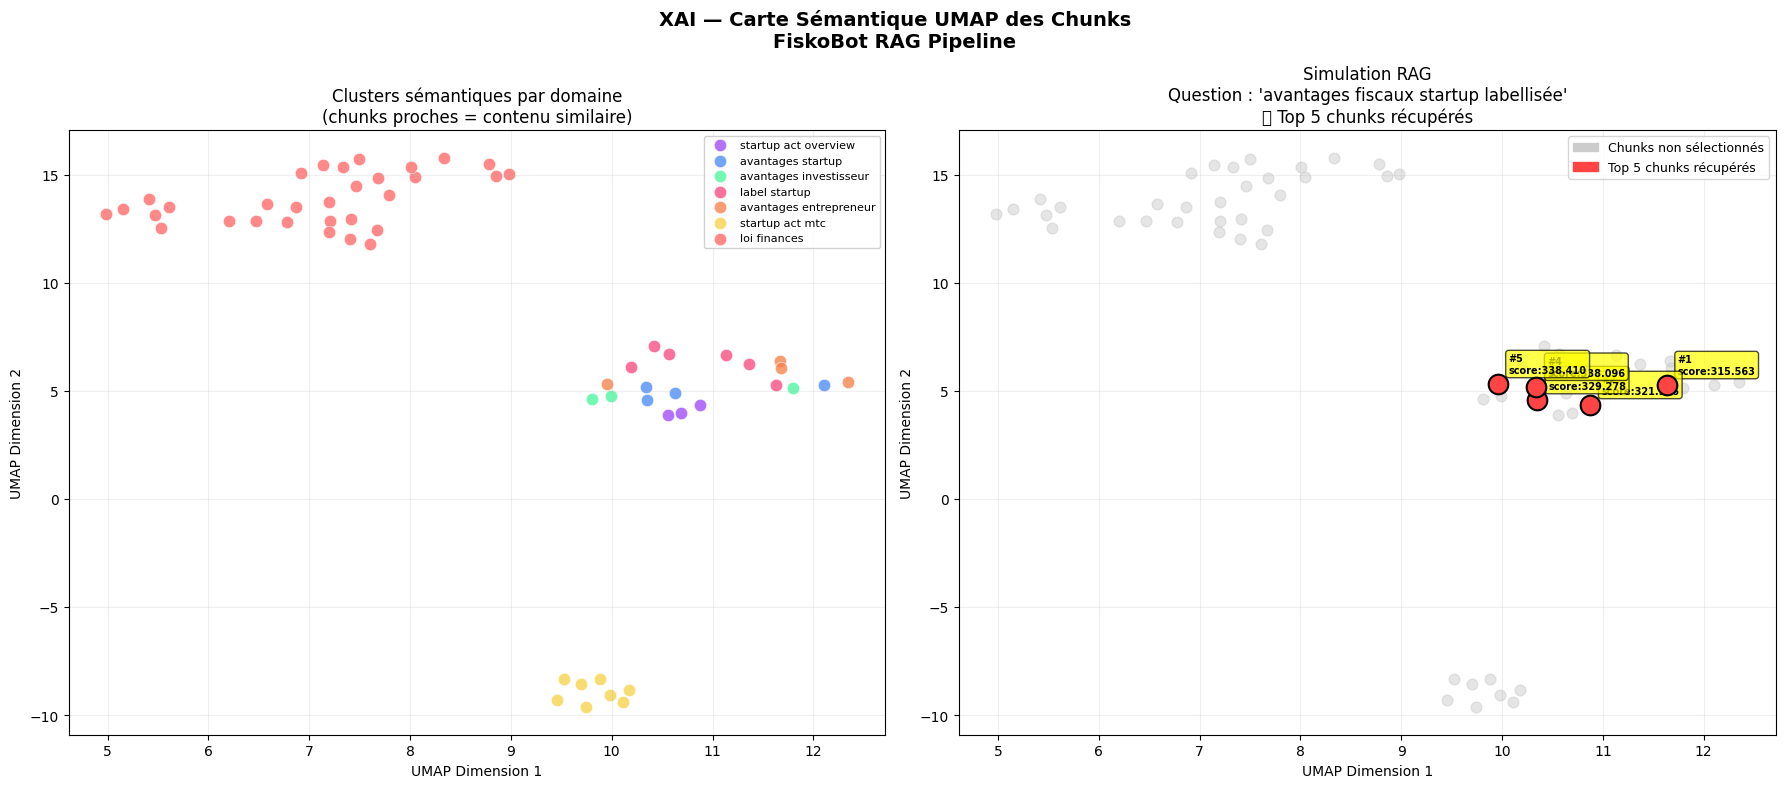


📋 EXPLICATION XAI — Pourquoi ces chunks ont été choisis

#1 — Score similarité : 315.5629
   Source  : Comment obtenir le label Startup
   Domaine : label_startup
   Extrait : Vous êtes une startup internationale et vous souhaitez créer votre filiale en Tunisie ?
Zoom sur les signaux de la galaxie  des startups
📢COMMUNIQUÉ –...


#2 — Score similarité : 321.9458
   Source  : Startup Act — Vue d'ensemble
   Domaine : startup_act_overview
   Extrait : You have an international startup and want to create your subsidiary in Tunisia?
Raise Capital for startups in Tunisia
Up to €200M to create a new fin...


#3 — Score similarité : 329.2781
   Source  : Avantages Startups — Startup Act
   Domaine : avantages_startup
   Extrait : Booster la constellation des startups
Découvrez les nombreux avantages du Startup Act pour les startups
Portail des startups :
Pensé pour être le poin...


#4 — Score similarité : 338.0962
   Source  : Avantages Startups — Startup Act
   Domaine : avantages_startup


In [30]:
# ════════════════════════════════════════════════════════════
# CELLULE XAI — UMAP : Carte sémantique des chunks
# ════════════════════════════════════════════════════════════

!pip install -q umap-learn matplotlib scikit-learn

import umap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import LabelEncoder

print("🔄 Récupération des vecteurs depuis ChromaDB...")

# ── Récupère tous les vecteurs + métadonnées ──────────────────
collection = vectorstore._collection
results    = collection.get(include=["embeddings", "metadatas", "documents"])

vectors   = np.array(results["embeddings"])
metadatas = results["metadatas"]
documents = results["documents"]

print(f"✅ {len(vectors)} vecteurs récupérés — {vectors.shape[1]} dimensions chacun")

# ── Réduction UMAP 768D → 2D ──────────────────────────────────
print("🧠 Réduction UMAP en cours (768 dimensions → 2D)...")
reducer    = umap.UMAP(n_neighbors=5, min_dist=0.3, random_state=42)
vectors_2d = reducer.fit_transform(vectors)
print("✅ Réduction terminée")

# ── Prépare les couleurs par domaine ─────────────────────────
domaines = [m.get("domaine", "inconnu") for m in metadatas]
langues  = [m.get("langue",  "fr")      for m in metadatas]
titres   = [m.get("titre",   "?")       for m in metadatas]

domaine_unique = list(set(domaines))
couleurs_map   = {
    "avantages_startup":    "#4F8EF7",
    "avantages_entrepreneur":"#F7844F",
    "avantages_investisseur":"#4FF7A0",
    "label_startup":         "#F74F84",
    "startup_act_overview":  "#A04FF7",
    "startup_act_mtc":       "#F7D44F",
    "loi_finances":          "#FF6B6B",
    "inconnu":               "#AAAAAA",
}

# ── Figure principale ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("XAI — Carte Sémantique UMAP des Chunks\nFiskoBot RAG Pipeline", fontsize=14, fontweight="bold")

# ── Graphe 1 : Carte par domaine ─────────────────────────────
ax1 = axes[0]
for domaine in domaine_unique:
    idx     = [i for i, d in enumerate(domaines) if d == domaine]
    couleur = couleurs_map.get(domaine, "#AAAAAA")
    ax1.scatter(
        vectors_2d[idx, 0],
        vectors_2d[idx, 1],
        c=couleur, label=domaine.replace("_"," "),
        s=80, alpha=0.8, edgecolors="white", linewidth=0.5
    )

ax1.set_title("Clusters sémantiques par domaine\n(chunks proches = contenu similaire)")
ax1.set_xlabel("UMAP Dimension 1")
ax1.set_ylabel("UMAP Dimension 2")
ax1.legend(loc="best", fontsize=8, framealpha=0.9)
ax1.grid(True, alpha=0.2)

# ── Graphe 2 : Simulation d'une question ─────────────────────
ax2 = axes[1]

# Plot tous les chunks en gris
ax2.scatter(vectors_2d[:, 0], vectors_2d[:, 1],
            c="#CCCCCC", s=60, alpha=0.5, label="Chunks non sélectionnés")

# Simule une question et trouve les top 5
question_test = "avantages fiscaux startup labellisée"
print(f"\n🔍 Simulation RAG pour : '{question_test}'")

top_docs = vectorstore.similarity_search_with_score(question_test, k=5)
top_titres = [d.metadata.get("titre","") for d, _ in top_docs]
top_scores = [score for _, score in top_docs]

# Trouve les indices des top chunks dans notre dataset
top_indices = []
for doc, score in top_docs:
    for i, text in enumerate(documents):
        if text == doc.page_content:
            top_indices.append((i, score))
            break

# Plot les top 5 en rouge avec annotation
for rank, (idx, score) in enumerate(top_indices):
    ax2.scatter(vectors_2d[idx, 0], vectors_2d[idx, 1],
                c="#FF4444", s=200, alpha=1.0,
                edgecolors="black", linewidth=1.5, zorder=5)
    ax2.annotate(
        f"#{rank+1}\nscore:{score:.3f}",
        (vectors_2d[idx, 0], vectors_2d[idx, 1]),
        textcoords="offset points", xytext=(8, 8),
        fontsize=7, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7)
    )

ax2.set_title(f"Simulation RAG\nQuestion : '{question_test}'\n🔴 Top 5 chunks récupérés")
ax2.set_xlabel("UMAP Dimension 1")
ax2.set_ylabel("UMAP Dimension 2")

legend_elements = [
    mpatches.Patch(color="#CCCCCC", label="Chunks non sélectionnés"),
    mpatches.Patch(color="#FF4444", label="Top 5 chunks récupérés"),
]
ax2.legend(handles=legend_elements, fontsize=9)
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("/kaggle/working/xai_umap.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Explication textuelle ─────────────────────────────────────
print("\n" + "="*60)
print("📋 EXPLICATION XAI — Pourquoi ces chunks ont été choisis")
print("="*60)
for rank, (doc, score) in enumerate(top_docs, 1):
    print(f"""
#{rank} — Score similarité : {score:.4f}
   Source  : {doc.metadata.get('titre','')}
   Domaine : {doc.metadata.get('domaine','')}
   Extrait : {doc.page_content[:150]}...
""")

print("="*60)
print("🧠 CE QUE MONTRE LE GRAPHIQUE UMAP")
print("="*60)
print("""
1. Chaque point = un chunk de tes documents
2. Points proches = contenu sémantiquement similaire
3. Clusters colorés = domaines bien séparés
   → preuve que ChromaDB organise bien la connaissance

4. Points rouges = chunks récupérés pour cette question
   → XAI : on voit EXACTEMENT pourquoi ces chunks
     ont été choisis — ils sont proches de la question
     dans l'espace vectoriel à 768 dimensions
""")
print("✅ Graphique sauvegardé : /kaggle/working/xai_umap.png")